# AI Loan Advisory Chatbot using Machine Learning and NLP



## 1. Project Objective

The objective of this project is to build an AI-based Loan Advisory Chatbot that can:

- Predict loan eligibility using applicant details.
- Give simple loan-related guidance through chatbot responses.
- Help users understand whether their profile is suitable for loan approval.
- Demonstrate preprocessing, ML model training, evaluation, and basic NLP-based chatbot logic.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


## 2. Upload Dataset File

Upload your loan dataset CSV file here.

Recommended dataset columns may include:
`Gender`, `Married`, `Dependents`, `Education`, `Self_Employed`, `ApplicantIncome`, `CoapplicantIncome`, `LoanAmount`, `Loan_Amount_Term`, `Credit_History`, `Property_Area`, `Loan_Status`

The target column should be **Loan_Status** or any similar loan approval column.

In [2]:
# Upload CSV file in Google Colab
from google.colab import files

uploaded = files.upload()

# Read uploaded CSV file
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("Dataset uploaded successfully:", file_name)
df.head()

Saving loan_approval_dataset.csv to loan_approval_dataset.csv
Saving test_Y3wMUE5_7gLdaTN.csv to test_Y3wMUE5_7gLdaTN.csv
Saving train_u6lujuX_CVtuZ9i.csv to train_u6lujuX_CVtuZ9i.csv
Dataset uploaded successfully: loan_approval_dataset.csv


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## 3. Basic Dataset Information

In [3]:
print("Shape of dataset:", df.shape)
print("\nColumns in dataset:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Shape of dataset: (4269, 13)

Columns in dataset:
['loan_id', ' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_

In [4]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64


## 4. Data Cleaning and Preprocessing

In this step, missing values are handled and categorical columns are encoded into numerical format.

In [5]:
# Make a copy of original data
data = df.copy()

# Drop ID type column if present
for col in data.columns:
    if 'id' in col.lower():
        data.drop(columns=[col], inplace=True)

# Fill missing values
for col in data.columns:
    if data[col].dtype == 'object':
        data[col].fillna(data[col].mode()[0], inplace=True)
    else:
        data[col].fillna(data[col].median(), inplace=True)

print("Missing values after cleaning:")
print(data.isnull().sum())

Missing values after cleaning:
no_of_dependents           0
education                  0
self_employed              0
income_annum               0
loan_amount                0
loan_term                  0
cibil_score                0
commercial_assets_value    0
luxury_assets_value        0
bank_asset_value           0
loan_status                0
dtype: int64


In [6]:
# Encode categorical columns
label_encoders = {}

for col in data.select_dtypes(include='object').columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

print("Categorical encoding completed")
data.head()

Categorical encoding completed


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,8200000,29400000,5000000,1


## 5. Exploratory Data Analysis (EDA)

In [7]:
# Statistical summary
data.describe()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
count,4269.000000,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4269.000000
mean,2.498712,0.497775,0.503631,5.059124e+06,1.513345e+07,10.900445,599.936051,4.973155e+06,1.512631e+07,4.976692e+06,0.377840
std,1.695910,0.500054,0.500045,2.806840e+06,9.043363e+06,5.709187,172.430401,4.388966e+06,9.103754e+06,3.250185e+06,0.484904
min,0.000000,0.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,0.000000e+00,3.000000e+05,0.000000e+00,0.000000
25%,1.000000,0.000000,0.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,1.300000e+06,7.500000e+06,2.300000e+06,0.000000
50%,3.000000,0.000000,1.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,3.700000e+06,1.460000e+07,4.600000e+06,0.000000
75%,4.000000,1.000000,1.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,7.600000e+06,2.170000e+07,7.100000e+06,1.000000
max,5.000000,1.000000,1.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,1.940000e+07,3.920000e+07,1.470000e+07,1.000000


In [8]:
import re

# Target column detection
possible_targets = ['Loan_Status', 'loan_status', 'Approval_Status', 'approval_status', 'Status', 'status', 'Approved', 'approved']
target_col = None

# Clean column names in data DataFrame to remove leading/trailing spaces
data.columns = [col.strip() for col in data.columns]

for col in possible_targets:
    if col in data.columns:
        target_col = col
        break

if target_col is None:
    print("Target column not found automatically.")
    print("Available columns:", data.columns.tolist())

    # Attempt to find a column that is a case-insensitive match for 'loan_status'
    for c in data.columns:
        if c.lower() == 'loan_status':
            target_col = c
            break

    if target_col is None:
        # Fallback if no 'loan_status' column found, prompt user
        target_col = input("Enter target column name exactly: ")

print("Target column selected:", target_col)

Target column selected: loan_status


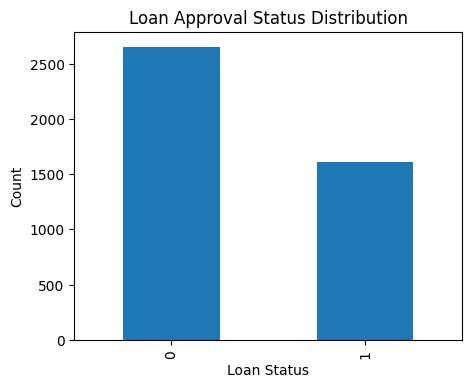

In [9]:
# Target distribution
plt.figure(figsize=(5,4))
data['loan_status'].value_counts().plot(kind='bar')
plt.title('Loan Approval Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

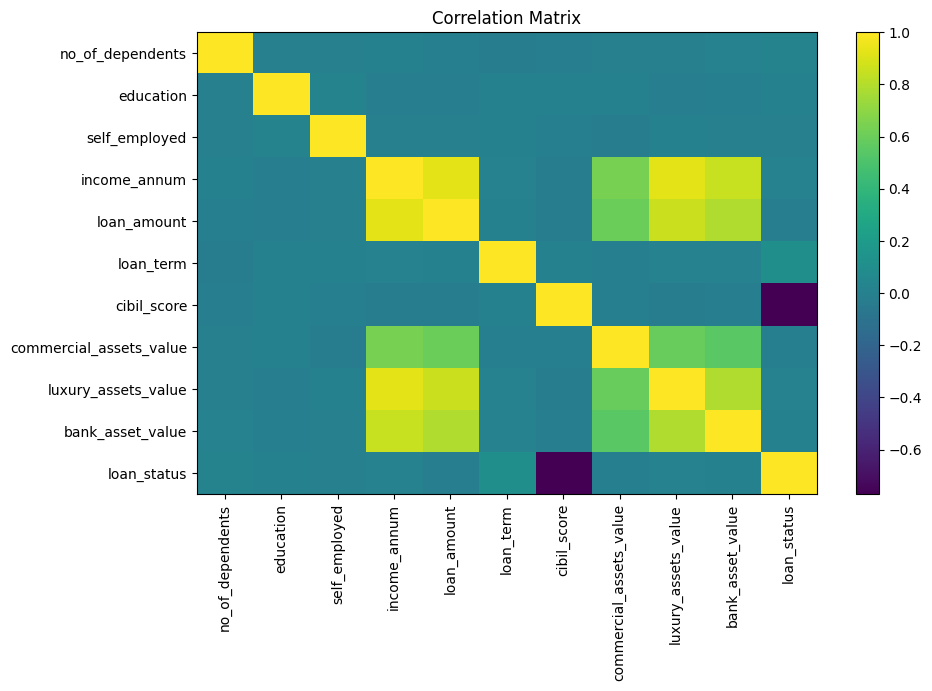

In [10]:
# Correlation heatmap using matplotlib
corr = data.corr()
plt.figure(figsize=(10,6))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Matrix')
plt.show()

## 6. Feature Selection and Train-Test Split

In [11]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=3000,
        C=10
    ),

    'Decision Tree': DecisionTreeClassifier(
        max_depth=8,
        min_samples_split=4,
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=500,
        max_depth=12,
        min_samples_split=4,
        random_state=42
    )
}

## 7. Feature Scaling

In [12]:
# Separate features (X) and target (y)
X = data.drop(columns=[target_col])
y = data[target_col]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed")

Feature scaling completed


## 8. Model Training

Three classification models are trained:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier

In [13]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

Logistic Regression Accuracy: 0.9063
Decision Tree Accuracy: 0.9813
Random Forest Accuracy: 0.9836


## 9. Model Evaluation

In [14]:
# Best model selection
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("Best Model:", best_model_name)
print("Best Accuracy:", results[best_model_name])

if best_model_name == 'Logistic Regression':
    final_pred = best_model.predict(X_test_scaled)
else:
    final_pred = best_model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, final_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, final_pred))

Best Model: Random Forest
Best Accuracy: 0.9836065573770492

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       536
           1       0.98      0.97      0.98       318

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854

Confusion Matrix:
[[531   5]
 [  9 309]]


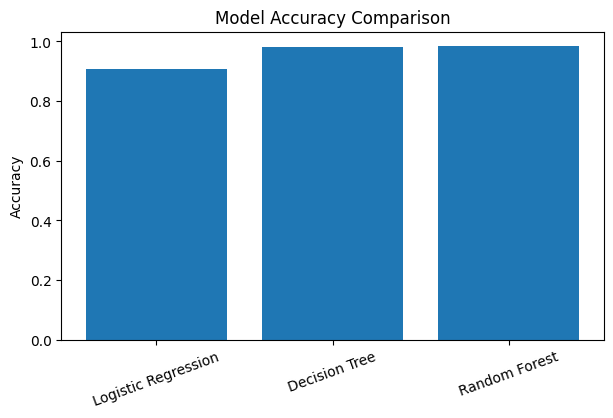

In [15]:
# Model comparison graph
plt.figure(figsize=(7,4))
plt.bar(results.keys(), results.values())
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=20)
plt.show()

## 10. Loan Advisory Function

This function takes user input and predicts whether the loan may be approved or not.

**Note:** Input values should match the dataset column format.

In [16]:
def predict_loan_eligibility(input_data):
    input_df = pd.DataFrame([input_data])

    # Encode categorical input values using saved encoders
    for col, le in label_encoders.items():
        if col in input_df.columns and col != target_col:
            try:
                input_df[col] = le.transform(input_df[col])
            except ValueError:
                input_df[col] = 0

    # Ensure same column order
    input_df = input_df[X.columns]

    if best_model_name == 'Logistic Regression':
        input_scaled = scaler.transform(input_df)
        prediction = best_model.predict(input_scaled)[0]
    else:
        prediction = best_model.predict(input_df)[0]

    # Decode target output if possible
    if target_col in label_encoders:
        prediction_label = label_encoders[target_col].inverse_transform([prediction])[0]
    else:
        prediction_label = prediction

    return prediction_label

## 11. Basic NLP Chatbot Logic

This chatbot provides simple loan-related answers and can also guide the user about eligibility prediction.

In [17]:
def loan_chatbot(user_message):
    msg = user_message.lower()

    if 'eligibility' in msg or 'eligible' in msg:
        return 'Loan eligibility depends on income, credit history, loan amount, employment status, and property area.'
    elif 'credit' in msg:
        return 'Credit history is an important factor. A good credit history increases loan approval chances.'
    elif 'income' in msg:
        return 'Higher and stable income usually improves loan approval probability.'
    elif 'document' in msg:
        return 'Common documents include ID proof, address proof, income proof, bank statement, and employment details.'
    elif 'interest' in msg:
        return 'Interest rate depends on bank policy, credit score, income, loan type, and repayment capacity.'
    elif 'loan amount' in msg:
        return 'Loan amount should be selected based on income, repayment capacity, and credit profile.'
    else:
        return 'I can help with loan eligibility, credit history, income, loan amount, documents, and interest rate queries.'

# Test chatbot
print(loan_chatbot('How can I check loan eligibility?'))
print(loan_chatbot('Why credit history is important?'))

Loan eligibility depends on income, credit history, loan amount, employment status, and property area.
Credit history is an important factor. A good credit history increases loan approval chances.


**RAG-Based Loan Policy Question**

In [18]:
!pip install -q langchain
!pip install -q langchain-community
!pip install -q langchain-text-splitters
!pip install -q sentence-transformers
!pip install -q faiss-cpu
!pip install -q pypdf
!pip install -q reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 22.2 MB/s eta 0:00:00


In [19]:
from reportlab.pdfgen import canvas

pdf_name = "loan_policy.pdf"

c = canvas.Canvas(pdf_name)

y = 800

content = [
    "Loan Policy Guidelines",
    "",
    "Eligibility Criteria:",
    "- Applicant must be at least 21 years old.",
    "- Applicant must have a stable source of income.",
    "- Minimum annual income should be Rs. 300000.",
    "- Credit score above 650 is preferred.",
    "",
    "Required Documents:",
    "- Aadhaar Card",
    "- PAN Card",
    "- Salary Slips (Last 3 Months)",
    "- Bank Statements (Last 6 Months)",
    "- Address Proof",
    "",
    "Loan Rules:",
    "- Maximum loan tenure is 30 years.",
    "- EMI should not exceed 50 percent of monthly income.",
    "- Interest rate ranges from 8 percent to 12 percent.",
    "",
    "EMI Information:",
    "- EMI depends on loan amount, tenure, and interest rate.",
    "- Early repayment may attract charges depending on policy."
]

for line in content:
    c.drawString(50, y, line)
    y -= 20

c.save()

print("loan_policy.pdf created successfully")

loan_policy.pdf created successfully


In [20]:
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader("loan_policy.pdf")

documents = loader.load()

print("Pages Loaded:", len(documents))

Pages Loaded: 1


In [21]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)

docs = text_splitter.split_documents(documents)

print("Total Chunks:", len(docs))

Total Chunks: 2


In [22]:
from langchain_community.embeddings import HuggingFaceEmbeddings

embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

print("Embeddings Generated Successfully")

/tmp/ipykernel_785/4077057098.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embeddings Generated Successfully


In [23]:
from langchain_community.vectorstores import FAISS

vector_store = FAISS.from_documents(
    docs,
    embedding_model
)

print("FAISS Vector Database Created")

FAISS Vector Database Created


In [24]:
question = "What are the loan eligibility criteria?"

retriever = vector_store.as_retriever(
    search_kwargs={"k": 2}
)

retrieved_docs = retriever.invoke(question)

for i, doc in enumerate(retrieved_docs):
    print(f"\nDocument {i+1}")
    print(doc.page_content)


Document 1
Loan Policy Guidelines
Eligibility Criteria:
- Applicant must be at least 21 years old.
- Applicant must have a stable source of income.
- Minimum annual income should be Rs. 300000.
- Credit score above 650 is preferred.
Required Documents:
- Aadhaar Card
- PAN Card
- Salary Slips (Last 3 Months)
- Bank Statements (Last 6 Months)
- Address Proof
Loan Rules:
- Maximum loan tenure is 30 years.
- EMI should not exceed 50 percent of monthly income.

Document 2
- Interest rate ranges from 8 percent to 12 percent.
EMI Information:
- EMI depends on loan amount, tenure, and interest rate.
- Early repayment may attract charges depending on policy.


In [25]:
def loan_policy_assistant(query):

    retrieved_docs = retriever.invoke(query)

    response = ""

    for doc in retrieved_docs:
        response += doc.page_content + "\n"

    return response

In [26]:
query = "What documents are required for loan approval?"

answer = loan_policy_assistant(query)

print("Question:", query)
print("\nAnswer:")
print(answer)

Question: What documents are required for loan approval?

Answer:
Loan Policy Guidelines
Eligibility Criteria:
- Applicant must be at least 21 years old.
- Applicant must have a stable source of income.
- Minimum annual income should be Rs. 300000.
- Credit score above 650 is preferred.
Required Documents:
- Aadhaar Card
- PAN Card
- Salary Slips (Last 3 Months)
- Bank Statements (Last 6 Months)
- Address Proof
Loan Rules:
- Maximum loan tenure is 30 years.
- EMI should not exceed 50 percent of monthly income.
- Interest rate ranges from 8 percent to 12 percent.
EMI Information:
- EMI depends on loan amount, tenure, and interest rate.
- Early repayment may attract charges depending on policy.



In [ ]:
while True:

    user_query = input("\nAsk a Loan Policy Question (type 'exit' to quit): ")

    if user_query.lower() == "exit":
        print("Chatbot Closed")
        break

    print("\nAnswer:")
    print(loan_policy_assistant(user_query))


Ask a Loan Policy Question (type 'exit' to quit): What documents are required for a home loan?

Answer:
Loan Policy Guidelines
Eligibility Criteria:
- Applicant must be at least 21 years old.
- Applicant must have a stable source of income.
- Minimum annual income should be Rs. 300000.
- Credit score above 650 is preferred.
Required Documents:
- Aadhaar Card
- PAN Card
- Salary Slips (Last 3 Months)
- Bank Statements (Last 6 Months)
- Address Proof
Loan Rules:
- Maximum loan tenure is 30 years.
- EMI should not exceed 50 percent of monthly income.
- Interest rate ranges from 8 percent to 12 percent.
EMI Information:
- EMI depends on loan amount, tenure, and interest rate.
- Early repayment may attract charges depending on policy.


Ask a Loan Policy Question (type 'exit' to quit): What is the minimum age for a loan?

Answer:
Loan Policy Guidelines
Eligibility Criteria:
- Applicant must be at least 21 years old.
- Applicant must have a stable source of income.
- Minimum annual income s

## 12. Sample Prediction

Edit the values below according to your uploaded dataset columns.

Run `X.columns` first to see the required input columns.

In [28]:
from sklearn.preprocessing import LabelEncoder

# Re-initialize label_encoders to ensure it's properly populated if cleared.
label_encoders = {}

# Create a temporary copy of df to get original string values and clean column names
# This ensures we fit encoders on the correct data and column names expected by the model.
temp_df = df.copy()
temp_df.columns = [col.strip() for col in temp_df.columns]

# Identify categorical columns that were used for encoding in cell 28b2a3c7
# These include features ('education', 'self_employed') and the target ('loan_status')
# as they are object type in the 'data' DataFrame before encoding.
categorical_cols_to_encode = []
for col in temp_df.columns:
    if temp_df[col].dtype == 'object':
        # Ensure these are the columns relevant for prediction and target decoding
        if col in ['education', 'self_employed', target_col]: # target_col is 'loan_status'
            categorical_cols_to_encode.append(col)

for col in categorical_cols_to_encode:
    le = LabelEncoder()
    # Fit the encoder using the original string values from temp_df
    # Convert to string to handle potential mixed types or NaNs gracefully for LabelEncoder
    le.fit(temp_df[col].astype(str))
    label_encoders[col] = le

print("Label encoders re-initialized for sample prediction based on actual dataset categorical columns.")

Label encoders re-initialized for sample prediction based on actual dataset categorical columns.


In [29]:
print("Input columns required:")
print(X.columns.tolist())

Input columns required:
['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


In [30]:
sample_input = {
    'no_of_dependents': 1,
    'education': 1,
    'self_employed': 0,
    'income_annum': 1200000,
    'loan_amount': 2000000,
    'loan_term': 12,
    'cibil_score': 850,
    'commercial_assets_value': 500000,
    'luxury_assets_value': 1000000,
    'bank_asset_value': 800000
}

In [31]:
input_df = pd.DataFrame([sample_input])

prediction = models['Random Forest'].predict(input_df)

result = "Approved" if prediction[0] == 1 else "Rejected"

print("Predicted Loan Status:", result)

Predicted Loan Status: Rejected


In [32]:
print(X.columns.tolist())

['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


## 13. Final Insights

- The dataset was cleaned by handling missing values and encoding categorical variables.
- Multiple ML models were trained for loan eligibility prediction.
- The best-performing model was selected based on accuracy.
- The chatbot provides basic loan-related guidance using keyword-based NLP logic.
- This system can help users get quick loan eligibility information and general loan advice.

## 14. Conclusion

This project successfully demonstrates an AI Loan Advisory Chatbot using Machine Learning and basic NLP. The ML model predicts loan eligibility based on user financial and personal details, while the chatbot answers common loan-related queries. This project can be further improved by using advanced NLP models, real banking data, and a web-based interface using Streamlit or Flask.